# Engagement Score Recommendation System

1. Data Cleaning
2. EDA
3. Feature Engineering
4. Engagement Score
5. TF-IDF
6. Cosine Similarity
7. Recommendation Function


## Problem Statement
Traditional recommendation systems usually predict ratings only.
Các nền tảng hiện tjai như Netflix, Youtube và Tiktok tập trung nhiều hơn vào sự tương tác của người dùng

Dự án này nhằm mục đích xây dựng Recommendation System using a regression-based approach to predict user engagement scores for movies.

Hệ thống sẽ:
- Phân tích tập dữ liệu movie
- Dự đoán điểm tương tác
- Đề xuất những bộ phim có độ tương tác cao
- Kết hợp dự đoán hồi quy với độ tương đồng nội dung
Mục tiêu: Xây dựng 1 hệ thống khuyến nghị
1. Dự đoán điểm tương tác bằng phương pháp hồi quy
2. Sử dụng các đặc điểm nội dung phim như thể loại và thẻ
3. Dự đoán phim dựa trên mức độ tương tác

## Data collection
- Dataset: MoiveLens Dataset
- File used:
  + moive.csv
  + ratings.csv
  + tags.csv
- Source: https://grouplens.org/datasets/movielens/latest/?utm_source=chatgpt.com   (ml-latest-small)

#### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

### Load dataset

In [3]:
movies = pd.read_csv('data/movies.csv')
ratings = pd.read_csv('data/ratings.csv')
tags = pd.read_csv('data/tags.csv')

In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


##### Information
- movieId: unique movie ID
- title: movie title
- genres: movie genres

In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


##### Information
- User ID
- Movie ID
- User rating
- Rating timestamp (thời gian người dùng đánh giá phim)

In [6]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


##### Information    
Do người dùng tự gắn cho phim
- ID user
- ID movie
- tag (từ khóa mô tả phim)
- timestamp(thời gian gắn tag)

## 1) Data Cleaning

In [7]:
print(movies.shape)
print(ratings.shape)
print(tags.shape)

(9742, 3)
(100836, 4)
(3683, 4)


In [8]:
movies.info()
ratings.info()
tags.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB
<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   userId     3683 non-null   int64
 1   movieId    3683 non-null   int64
 2   tag        3683 non-null   str

##### Nhận xét:
1. Không có missing value
2. Movies
- 9742 bộ phim
- không có giá trị null
- cột genres chứ nhiều thể loại phim được phân tách bằng ký tự "|" -> cần xử lý: splitting, one-hot encoding
3. Ratings
- dùng để tính average rating, rating count, popularity
- tạo engagement score
4. Tags
- tags là dữ liệu text do người dùng tạo
- rất quan trọng: content-based filtering, TF-IDF vectorization, cosine similarity

In [9]:
movies.isnull().sum()
ratings.isnull().sum()
tags.isnull().sum()

userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

In [10]:
movies.duplicated().sum()
ratings.duplicated().sum()
tags.duplicated().sum()

np.int64(0)

In [11]:
ratings.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


##### Dataset ratings chứa:
- 100,836 lượt đánh giá phim
- từ 610 người dùng
1. Rating
- mean=3.5 dữ liệu phân bố tương đối cân bằng
- min=0.5
- max=5.0
- median=3.5 cho thấy người dùng có xu hướng đánh giá phim ở mức khá tốt
2. movieId
- mean=19435
- max=193609
- dataset chứa rất nhiều movie IDs khác nhau
- hệ thống recommendation có độ đa dạng cao
- phù hợp để xây dựng recommendation engine

### 2) EDA

#### 2.1. Convert timestamp
- số ratings theo năm
- user activity theo thời gian
- trend movies

In [12]:
# ratings
ratings['timestamp'] = pd.to_datetime(
    ratings['timestamp'],
    unit='s'
)
ratings['timestampyear'] = ratings['timestamp'].dt.year

In [13]:
ratings.head(1)

,userId,movieId,rating,timestamp,timestampyear
0,1,1,4.0,2000-07-30 18:45:03,2000


#### 2.2. Merge dataset

In [14]:
# Merge ratings + movies
df = ratings.merge(movies, on='movieId', how='left')

In [15]:
# Merge tags
df = df.merge(
    tags[['userId', 'movieId', 'tag']],
    on=['userId', 'movieId'],
    how='left'
)

In [16]:
df.shape

(102677, 8)

In [17]:
df.isnull().sum()

userId               0
movieId              0
rating               0
timestamp            0
timestampyear        0
title                0
genres               0
tag              99201
dtype: int64

- tag thiếu quá lớn vì không phải user nào cũng gắn tag chỉ có 3683 tag records trong khi 100836 ratings

In [18]:
df['tag'] = df['tag'].fillna('')    # đơn giản user không gắn tag

- rating.csv ban đầu không thiếu dữ liệu
- nên lỗi này thường do merge sai chiều

In [19]:
df.isnull().sum()

userId           0
movieId          0
rating           0
timestamp        0
timestampyear    0
title            0
genres           0
tag              0
dtype: int64

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 102677 entries, 0 to 102676
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype        
---  ------         --------------   -----        
 0   userId         102677 non-null  int64        
 1   movieId        102677 non-null  int64        
 2   rating         102677 non-null  float64      
 3   timestamp      102677 non-null  datetime64[s]
 4   timestampyear  102677 non-null  int32        
 5   title          102677 non-null  str          
 6   genres         102677 non-null  str          
 7   tag            102677 non-null  str          
dtypes: datetime64[s](1), float64(1), int32(1), int64(2), str(3)
memory usage: 5.9 MB


#### 2.3. Visualization

##### Rating Distribution

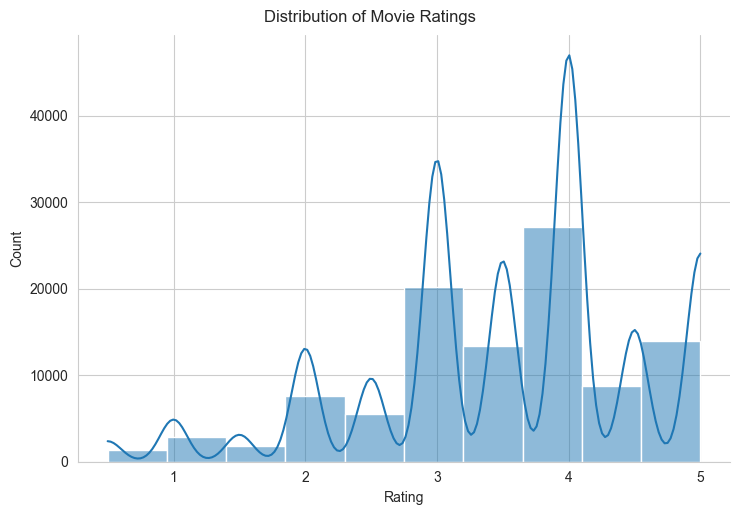

In [21]:
sns.set_style("whitegrid")

g = sns.displot(
    data=df,
    x="rating",
    bins=10,
    kde=True,
    height=5,
    aspect=1.5
)

g.fig.suptitle("Distribution of Movie Ratings", y=1.02)

plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

##### Top Genres

In [22]:
# Tách genres
genres = df['genres'].str.split('|').explode()

In [23]:
# Đếm genres
genres_count = genres.value_counts().head(10)

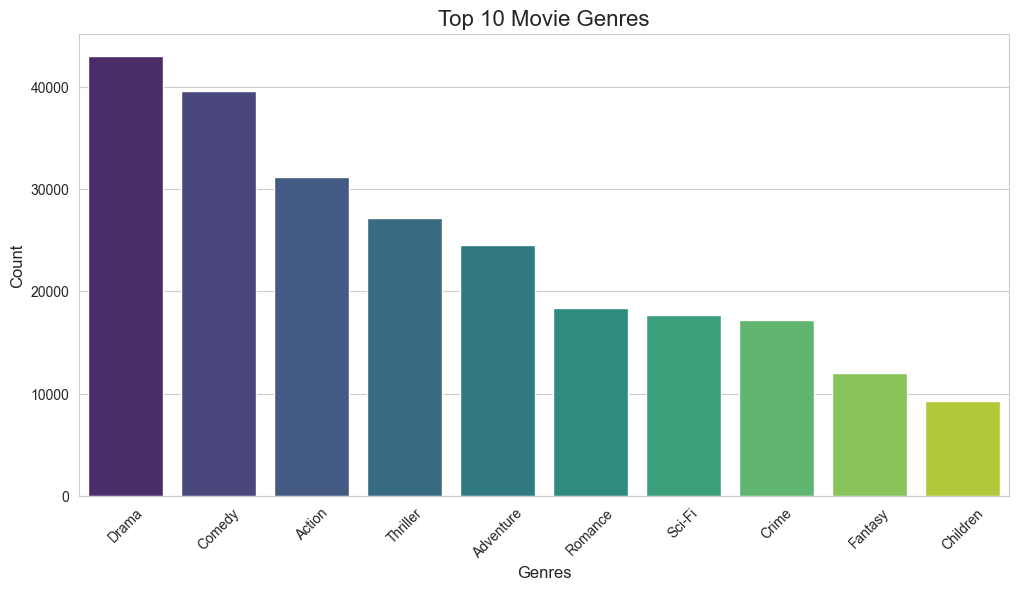

In [24]:
# Vẽ biểu đồ thể hiện top 10 thể loại phim
plt.figure(figsize=(12,6))

sns.barplot(
    x=genres_count.index,
    y=genres_count.values,
    palette = 'viridis'
)

plt.title("Top 10 Movie Genres", fontsize=16)
plt.xlabel("Genres", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.xticks(rotation=45)

plt.show()

##### Most Common Tags

In [25]:
tags_count = tags.value_counts().head(10)

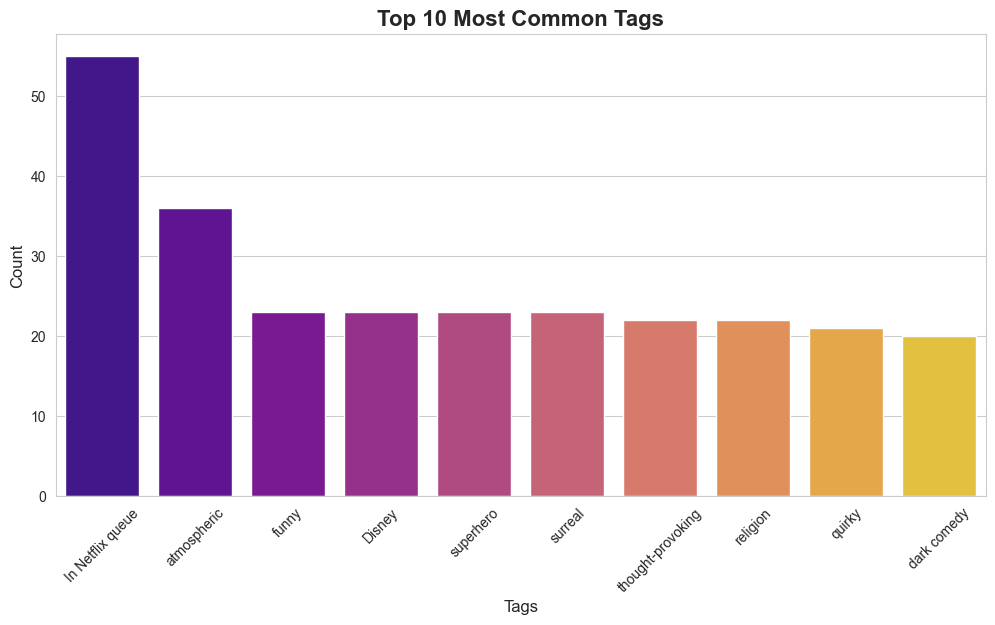

In [26]:
sns.set_style("whitegrid")

# Lấy top 10 tags phổ biến
tags_count = df[df['tag'] != '']['tag'] \
    .value_counts() \
    .head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=tags_count.index,
    y=tags_count.values,
    palette='plasma'
)

plt.title(
    "Top 10 Most Common Tags",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Tags", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.xticks(rotation=45)

plt.show()

##### Most Rated Movies

In [27]:
top_movies = df.groupby('title')['rating'].count().sort_values(ascending=False).head(10)

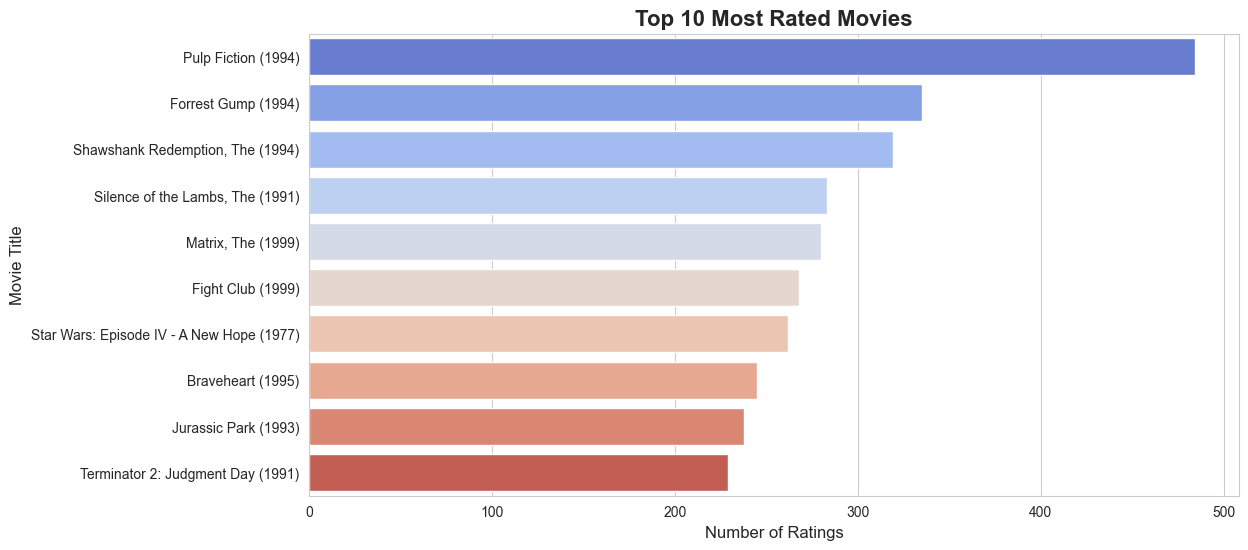

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_movies.values,
    y=top_movies.index,
    palette='coolwarm'
)

plt.title(
    "Top 10 Most Rated Movies",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Number of Ratings", fontsize=12)
plt.ylabel("Movie Title", fontsize=12)

plt.show()

##### Average Rating per Movie

In [29]:
# Lấy phim có ít nhất 50 ratings
movies_with_50_ratings = df.groupby('title').agg({
    'rating': ['mean', 'count']
})
movies_with_50_ratings.columns = ['avg_rating', 'rating_count']
filtered_movies = movies_with_50_ratings[movies_with_50_ratings['rating_count'] >= 50]
top_avg_movies = filtered_movies.sort_values(
    'avg_rating',
    ascending=False
).head(10)

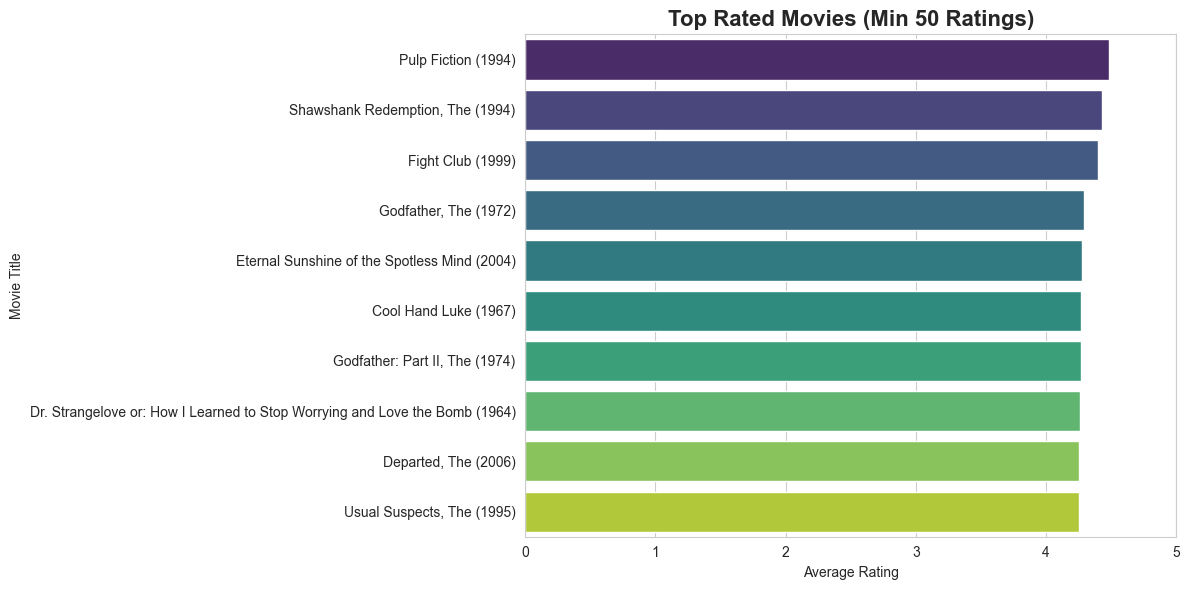

In [30]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_avg_movies['avg_rating'],
    y=top_avg_movies.index,
    palette='viridis'
)

plt.title(
    "Top Rated Movies (Min 50 Ratings)",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Average Rating")
plt.ylabel("Movie Title")

plt.xlim(0,5)

plt.tight_layout()

plt.show()

##### Ratings over Years

In [31]:
ratings_per_year = df['timestamp'].value_counts().sort_index()

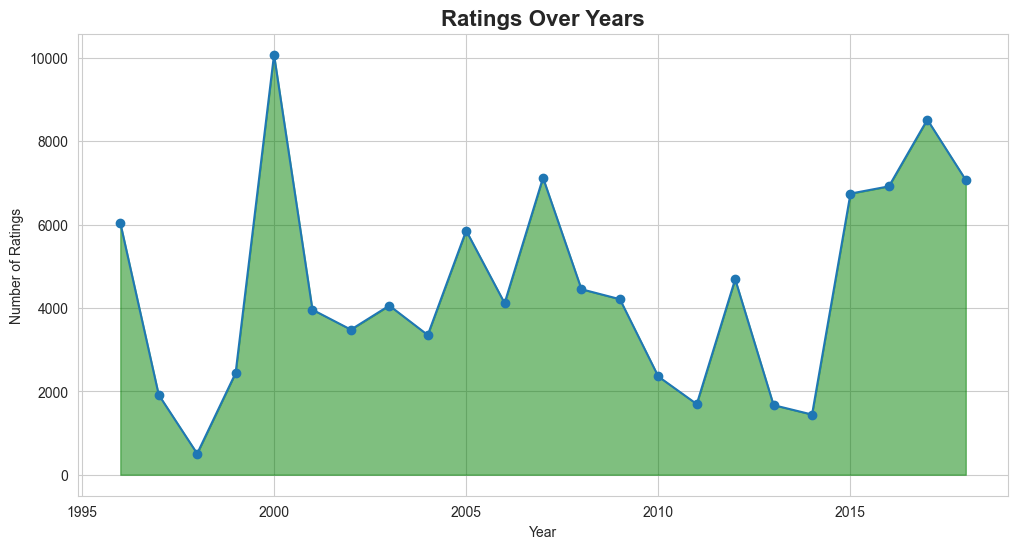

In [32]:
ratings_per_year = df['timestampyear'].value_counts().sort_index()

sns.set_style("whitegrid")

plt.figure(figsize=(12,6))

plt.fill_between(
    ratings_per_year.index,
    ratings_per_year.values,
    alpha=0.5,
    color='green'
)

plt.plot(
    ratings_per_year.index,
    ratings_per_year.values,
    marker='o'
)

plt.title(
    "Ratings Over Years",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Year")
plt.ylabel("Number of Ratings")

plt.show()

### 3) Feature Engineering

#### Popularity

In [33]:
rating_count = df.groupby('movieId')['rating'].count().reset_index()

rating_count.columns = ['movieId',
                        'rating_count']

#### Average Rating

In [34]:
avg_rating = df.groupby('movieId')['rating'].mean().reset_index()

avg_rating.columns = ['movieId', 'avg_rating']

#### Tag Count

In [35]:
tag_count = df[df['tag'] != ''].groupby('movieId')['tag'].count().reset_index()
tag_count.columns = [
    'movieId',
    'tag_count'
]

#### Merge Features

In [36]:
movie_features = movies.merge(
    avg_rating,
    on='movieId',
    how='left'
)

movie_features = movie_features.merge(
    rating_count,
    on='movieId',
    how='left'
)

movie_features = movie_features.merge(
    tag_count,
    on='movieId',
    how='left'
)

In [37]:
movie_features = movie_features.dropna(
    subset=['avg_rating', 'rating_count']
)

In [38]:
movie_features['tag_count'] = movie_features['tag_count'].fillna(0)

In [39]:
movie_features.isnull().sum()

movieId         0
title           0
genres          0
avg_rating      0
rating_count    0
tag_count       0
dtype: int64

## 4) Tiền xử lý dữ liệu
 #### 4.1. Normalize features

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

movie_features[
    [
        'avg_rating',
        'rating_count',
        'tag_count'
    ]
] = scaler.fit_transform(
    movie_features[
        [
            'avg_rating',
            'rating_count',
            'tag_count'
        ]
    ]
)

#### 4.2. Tạo engagement score
- Engagement Score = target - mức độ tương tác của người dùng với phim
- manual weights: EngagementScore = 0.6 x AvgRating + 0.25 x RatingCount + 0.15 x TagCount
  + AvgRating: chất lượng/phản hồi của người dùng
  + RatingCount: độ phổ biến của phim
  + TagCount: mức độ user interaction

In [41]:
movie_features['engagement_score'] = (
    0.6 * movie_features['avg_rating']
    + 0.25 * movie_features['rating_count']
    + 0.15 * movie_features['tag_count']
)

#### 4.3. Content Feature for Recommendation

In [42]:
movie_features['content'] = (
    movie_features['genres']
)

#### 4.4. TF-IDF Vectorization

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfid = TfidfVectorizer(stop_words='english')

tfid_matrix = tfid.fit_transform(
    movie_features['content']
)

#### 4.5. Cosine Similarity

In [44]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(
    tfid_matrix,
    tfid_matrix
)

In [45]:
movie_features = movie_features.reset_index()

In [46]:
# Tạo mapping title -> index
indices = pd.Series(
    movie_features.index,
    index=movie_features['title']
)

#### 4.6. Recommendation Function

In [47]:
def recommendation_movies(title, n=10):
    idx = indices[title]
    sim_scores = list(
        enumerate(cosine_sim[idx])
    )
    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )
    sim_scores = sim_scores[1:n+1]
    movie_indices = [
        i[0] for i in sim_scores
    ]
    return movie_features[
        ['title',
         'genres',
         'engagement_score']
    ].iloc[movie_indices]

In [48]:
recommendation_movies('Toy Story (1995)')

,title,genres,engagement_score
1705,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,0.335847
2353,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1.859955
2805,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,-0.757708
2996,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,0.574433
3563,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,1.708271
6177,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy,-0.652793
6469,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,-0.075644
6931,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy,-0.308268
7742,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy,1.069830
8201,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy,-0.652793


##### save movie_features.csv

In [49]:
movie_features.to_csv(
    'data/movie_features.csv',
    index=False
)